# 자전거 대여량 예측 모델

## 라이브러리 및 데이터 불러오기

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

import os # 파일 시스템 경로 작업을 위해 (CSV 파일 로드 시 유용)

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,cross_validate

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, \
        r2_score

In [2]:
train_df = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')
test_df = pd.read_csv('./data/bike_test.csv', encoding='euc-kr')

## 데이터 확인 및 전처리

In [3]:
train_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [4]:
test_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [5]:
pd.isnull(train_df).sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [ ]:
tr_df = train_df.drop('datetime', axis =1)

In [14]:
tx_df = test_df.drop('datetime', axis =1)

### 상관관계 분석

<Axes: >

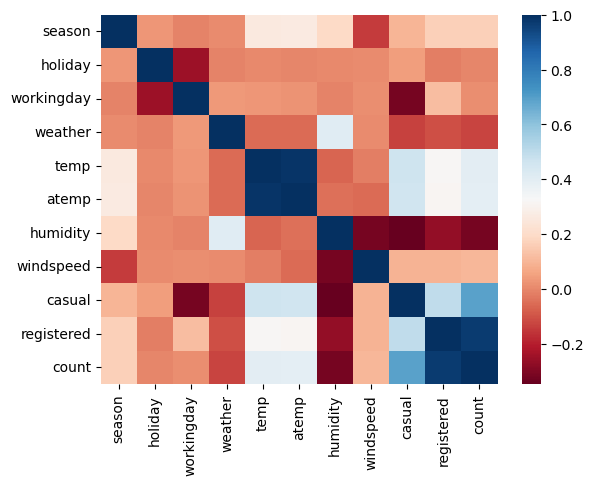

In [8]:
corr = tr_df.corr()
sns.heatmap(corr, cmap='RdBu')

### 이상치 탐지

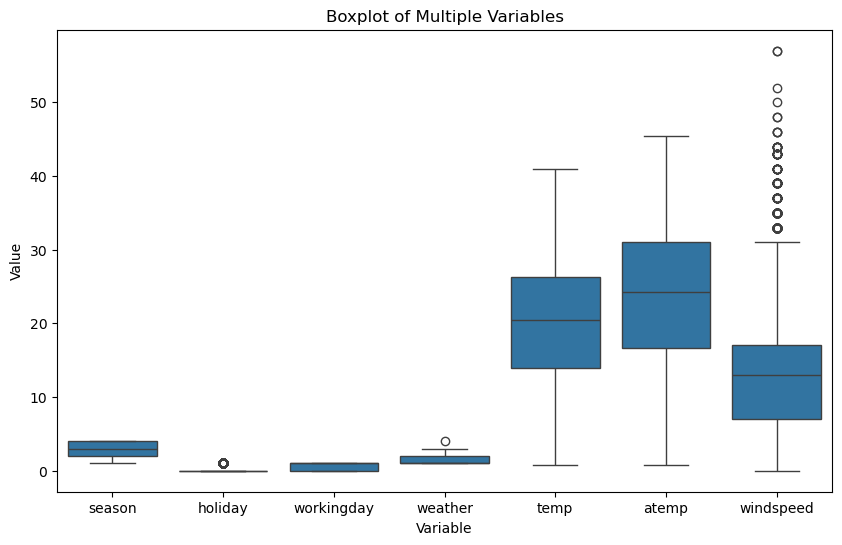

In [13]:
cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'windspeed']
df_melted = tr_df[cols].melt(var_name='Variable', value_name='Value')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxplot of Multiple Variables')
plt.show()

In [16]:
# 풍속 컬럼만 따로 가져오기
windspeed = tr_df['windspeed']

# IQR 계산
Q1 = windspeed.quantile(0.25)
Q3 = windspeed.quantile(0.75)
IQR = Q3 - Q1

# 이상치 기준
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 조건에 해당하는 인덱스 추출
outlier_idx = tr_df[(windspeed < lower_bound) | (windspeed > upper_bound)].index

print("이상치 인덱스:")
print(outlier_idx.tolist())


이상치 인덱스:
[175, 178, 194, 196, 265, 271, 471, 472, 473, 474, 479, 604, 605, 606, 608, 612, 613, 705, 749, 750, 752, 753, 754, 756, 757, 758, 760, 761, 762, 848, 850, 853, 860, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 873, 874, 875, 919, 920, 923, 924, 929, 1015, 1017, 1022, 1023, 1108, 1151, 1307, 1313, 1380, 1409, 1410, 1411, 1412, 1413, 1415, 1423, 1427, 1428, 1433, 1437, 1440, 1456, 1577, 1578, 1579, 1582, 1595, 1601, 1674, 1694, 1695, 1696, 1697, 1699, 1721, 1838, 1839, 1840, 1853, 1887, 1889, 2268, 2274, 2275, 2525, 2755, 2756, 2963, 3200, 3307, 3479, 3480, 3595, 3596, 3720, 3953, 4403, 4406, 4494, 4495, 4496, 4594, 4760, 4761, 4763, 4812, 5129, 5130, 5131, 5314, 5456, 5480, 5481, 5482, 5483, 5485, 5487, 5712, 5713, 5719, 5720, 5721, 5722, 5723, 5817, 5818, 5819, 5829, 5830, 5831, 5832, 5833, 5839, 5842, 5843, 5916, 5918, 5919, 6132, 6133, 6134, 6135, 6137, 6140, 6141, 6142, 6150, 6152, 6153, 6417, 6418, 6419, 6420, 6421, 6444, 6449, 6491, 6511, 6512, 6513, 6514, 6515, 651

In [17]:
tr_df1 = tr_df.drop(outlier_idx, axis=0)

In [24]:
tr_df2 = tr_df1.drop('humidity', axis = 1)
tr_df3 = tr_df2.drop('count', axis = 1)
X = tr_df3.drop(columns=['registered', 'casual'])
y = tr_df2['count']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                 y, 
                 test_size= 0.3, 
                 random_state= 156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False )),
    ('linear', LinearRegression())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [26]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False )),
    ('linear', LinearRegression())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,27003.310408,164.326840,0.188541
1,2,26086.799225,161.514084,0.216083
2,3,25256.831145,158.923979,0.241024
3,4,25655.729851,160.174061,0.229037


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                 y, 
                 test_size= 0.3, 
                 random_state= 156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False )),
    ('linear', RandomForestRegressor())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', RandomForestRegressor())])

In [28]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False )),
    ('linear', RandomForestRegressor())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,28202.688527,167.936561,0.152500
1,2,28077.509320,167.563449,0.156261
2,3,27923.652431,167.103718,0.160885
3,4,27900.778375,167.035261,0.161572
